In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random as random
from collections import deque

### Color Schema

- Green -> Tree (0)
- Gray -> Open Path (1)
- Black -> Wall (2)
- Yellow -> Quicksand (3)
- Red -> Hole (4)

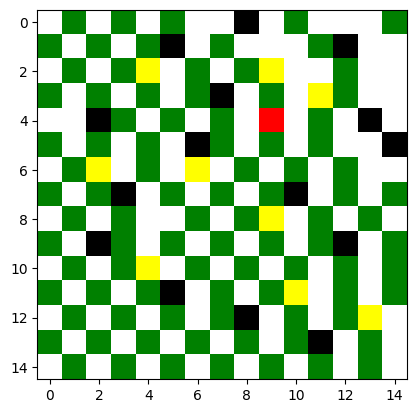

In [2]:


grid_map = np.array([
    [1, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 2, 1, 0, 1, 1, 1, 0, 2, 1, 1],
    [1, 0, 1, 0, 3, 1, 0, 1, 0, 3, 1, 1, 0, 1, 1],
    [0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 3, 0, 1, 1],
    [1, 1, 2, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1, 2, 1],
    [0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2],
    [1, 0, 3, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 1, 1],
    [0, 1, 0, 2, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 0],
    [1, 0, 1, 0, 1, 1, 0, 1, 0, 3, 1, 0, 1, 0, 1],
    [0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0],
    [1, 0, 1, 0, 3, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 2, 1, 0, 1, 0, 3, 1, 0, 1, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1, 0, 3, 1],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 1, 0, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
])
colors = ['green', 'white', 'black', 'yellow', 'red']
cmap = ListedColormap(colors)
plt.imshow(grid_map, cmap = cmap, vmin = 0, vmax = 4)

- Too Many Blocked Paths

In [3]:
obstacles = [0 , 2, 3 , 4]
passable = [1,3] #obstacles which allow passage

In [4]:
def bfs(grid, chosen , passable_neighbors,x,y):
    queue = deque([chosen]) #putting the source
    visited = {chosen}  #add all what we visited to this array, set of coordinates 
    #We need to temporarily block the {x,y} tile, so that the system doesn't mistake it for a path
    grid[x,y] = 2
    while queue:
        cx, cy = queue.popleft()
        
        #We need to explore its direct neighbors
        for dnx, dny in [(-1,0),(1,0),(0,-1),(0,1)]:
            #check if already visited
            if((cx+dnx,cy+dny) in visited):
                continue
            #check if passable
            if(grid[cx+dnx,cy+dny] not in passable):
                continue
            #check if in the neighbors 
            if((cx+dnx,cy+dny) in passable_neighbors):
                grid[x,y] = 1 #Unblock it
                return True
            #neither of both, we add it as visited and we add it to the queue
            queue.append((cx+dnx,cy+dny))
            visited.add((cx+dnx,cy+dny))
        
        grid[x,y] = 1
    return False

In [5]:

def build_grid(gridsize):
    hole_count = 0 #A map cannot have more 5% of it as holes. 
    if gridsize[0] < 10 or gridsize[1] < 10:
        print("Increase grid size!")
        return
    grid = np.ones(gridsize) #Create a grid, initially all passable
    #Creating walls around the map
    grid[0, :] = 2
    grid[: , 0] = 2
    grid[-1, : ] = 2
    grid[:, -1] = 2
    blocked_count = int(gridsize[0]*gridsize[1]*0.45) #45% of the grid must be blocked
    
    while blocked_count > 0 :
        #picking x and y by avoiding the edges
        x = random.randint(1,grid.shape[0]-2) 
        y = random.randint(1,grid.shape[1]-2)
        
        
        #making sure , the hole count does not exceed 5% of the map grid count
        while(True):
            obstacle = random.choice(obstacles)
            if obstacle == 4:
                #check hole counter
                if hole_count == int(gridsize[0]*gridsize[1]*0.05) :
                    continue
                else:
                    hole_count+=1
                    break;
            else:
                break #break if not a hole
        
        
        #if obstacle is a quicksand, we can insert it directly. It does not affect passability.
        #Just causes increased path cost
        if obstacle == 3:
            grid[x,y] = 3
            blocked_count-=1
        else: #obstacle NOT passable
            up = (x-1,y)
            down = (x+1,y)
            left = (x,y-1)
            right = (x,y+1)
            
            count = 0 #passable neigbors count

            passable_neigbors = [] #store all the passable neighbors
            temp = [up,down,left,right]
            
            for neighbor in temp:
                if grid[neighbor[0], neighbor[1]] in passable:
                    passable_neigbors.append((neighbor[0], neighbor[1]))
                    count+=1
                
            if count < 2:
                #safe to add the obstacle
                grid[x,y] = obstacle
                blocked_count-=1
            elif count >= 2:
                #choose a random neighbor and check the connectivity between all passable neighbors
                chosen = random.choice(passable_neigbors)
                state = bfs(grid,chosen,passable_neigbors,x,y)
                if state:
                    #safe to add
                    grid[x,y] = obstacle
                    blocked_count-=1
    return grid

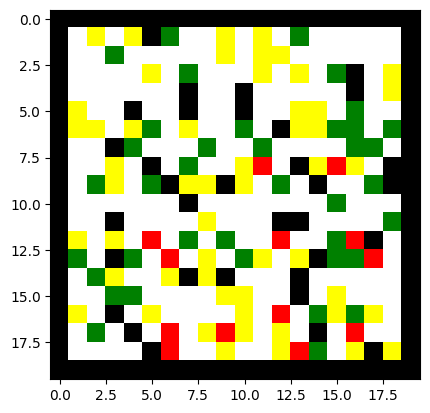

In [6]:
grid = build_grid((20,20))
plt.imshow(grid, cmap = cmap, vmin = 0, vmax = 4)